In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/excel2/emotions.csv
/kaggle/input/yidingkeyide/archive/images/7/Disgust.jpg
/kaggle/input/yidingkeyide/archive/images/7/Anger.jpg
/kaggle/input/yidingkeyide/archive/images/7/Sad.jpg
/kaggle/input/yidingkeyide/archive/images/7/Disgust (2).jpg
/kaggle/input/yidingkeyide/archive/images/7/Surprised (2).jpg
/kaggle/input/yidingkeyide/archive/images/7/Happy (2).jpg
/kaggle/input/yidingkeyide/archive/images/7/Neutral (2).jpg
/kaggle/input/yidingkeyide/archive/images/7/Contempt (2).jpg
/kaggle/input/yidingkeyide/archive/images/7/Anger (2).jpg
/kaggle/input/yidingkeyide/archive/images/7/Surprised.jpg
/kaggle/input/yidingkeyide/archive/images/7/Neutral.jpg
/kaggle/input/yidingkeyide/archive/images/7/Happy.jpg
/kaggle/input/yidingkeyide/archive/images/7/Fear.jpg
/kaggle/input/yidingkeyide/archive/images/7/Contempt.jpg
/kaggle/input/yidingkeyide/archive/images/7/Fear (2).jpg
/kaggle/input/yidingkeyide/archive/images/7/Sad (2).jpg
/kaggle/input/yidingkeyide/archive/images/17/Disgust.j

# importing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import itertools

# Loading datasets


In [ ]:
IMG_SIZE = 48

DATA_DIR = '/kaggle/input/yidingkeyide/archive/images'
EMOTIONS = ['Anger', 'Contempt', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprised']

# Load the dataset
csv_path = '/kaggle/input/3333333/emotions.csv'
emotions_df = pd.read_csv(csv_path)

# Data visualization

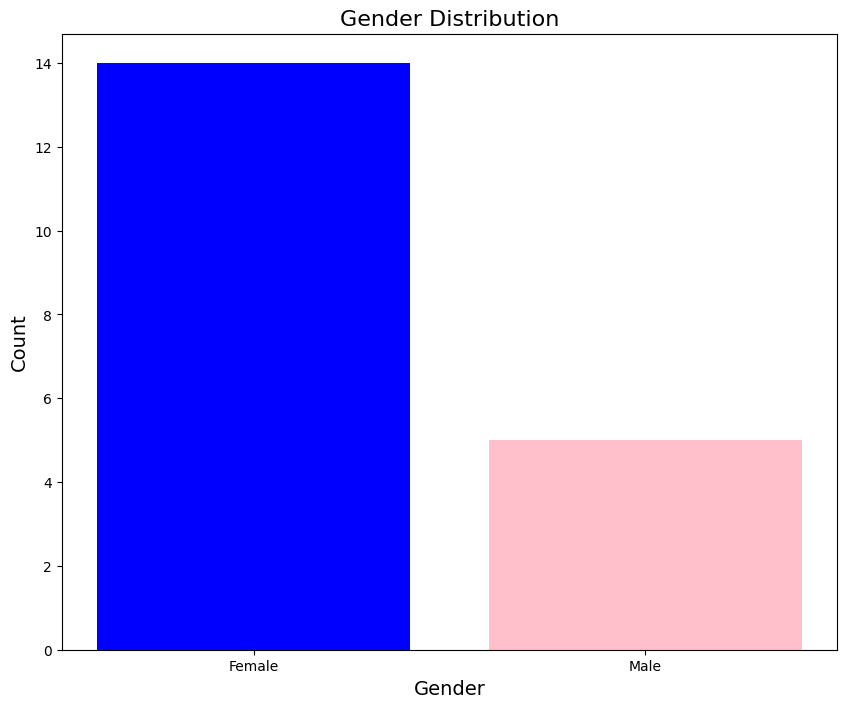

In [ ]:
plt.figure(figsize=(10, 8))
gender_counts = emotions_df['gender'].value_counts()
plt.bar(gender_counts.index, gender_counts.values, color=['blue', 'pink'])
plt.title('Gender Distribution', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks([0, 1], ['Female', 'Male'])
plt.show()

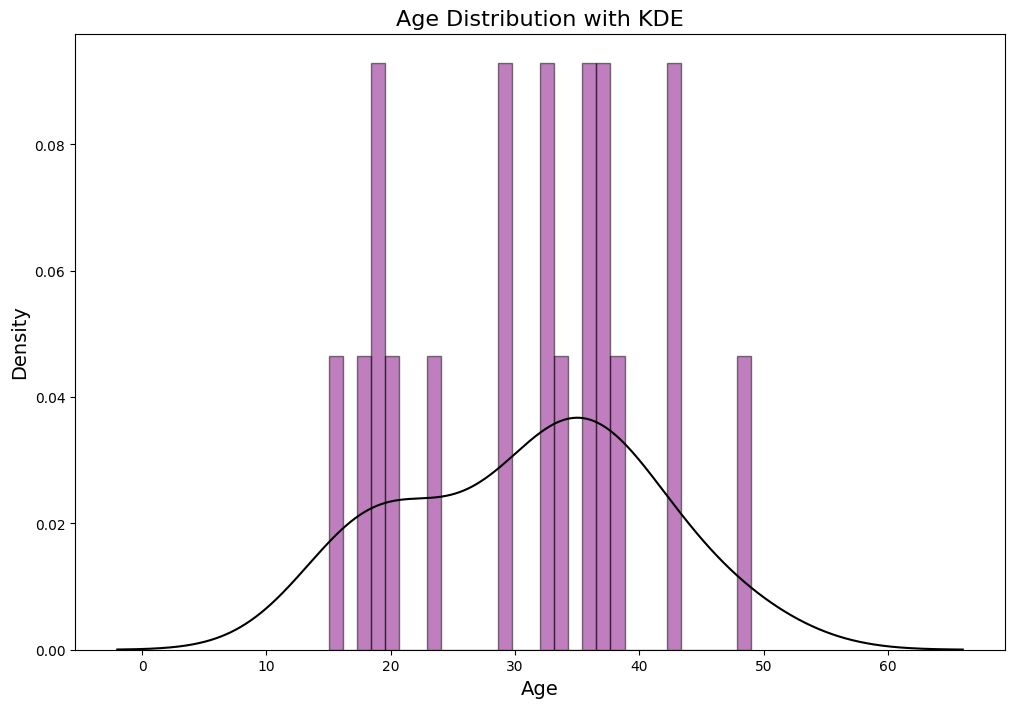

In [ ]:
plt.figure(figsize=(12, 8))
emotions_df['age'].plot(kind='hist', bins=30, density=True, alpha=0.5, color='purple', edgecolor='black')
emotions_df['age'].plot(kind='kde', color='black')
plt.title('Age Distribution with KDE', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.show()

<Figure size 1200x1000 with 0 Axes>

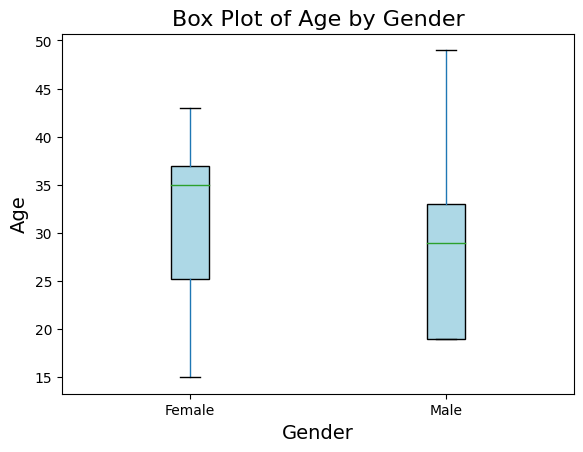

In [ ]:
# Box plot of age by gender
plt.figure(figsize=(12, 10))
emotions_df.boxplot(column='age', by='gender', grid=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Box Plot of Age by Gender', fontsize=16)
plt.suptitle('')
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Age', fontsize=14)
plt.xticks([1, 2], ['Female', 'Male'])
plt.show()


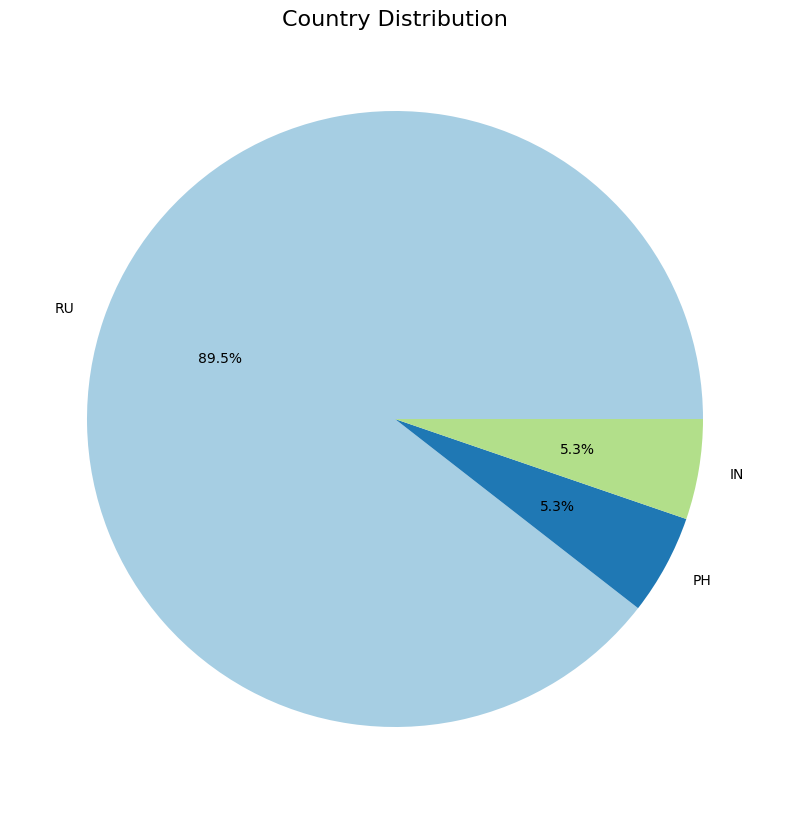

In [ ]:
# Pie chart for country distribution
country_counts = emotions_df['country'].value_counts()
plt.figure(figsize=(12, 10))
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', colors=plt.cm.Paired(np.arange(len(country_counts))))
plt.title('Country Distribution', fontsize=16)
plt.show()

# Function to load and preprocess images

In [ ]:

def load_data():
    images = []
    labels = []

    for emotion_label, emotion in enumerate(EMOTIONS):
        # Get the directory for the current emotion
        emotion_dir = os.path.join(DATA_DIR, str(emotion_label))
        if os.path.isdir(emotion_dir):
            for img_file in os.listdir(emotion_dir):
                img_path = os.path.join(emotion_dir, img_file)
                img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                img_resized = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                images.append(img_resized)
                labels.append(emotion_label)  # Assigning label based on index
        else:
            print(f"Directory not found for emotion {emotion}: {emotion_dir}")

    return np.array(images), np.array(labels)

# Load the data
images, labels = load_data()

In [ ]:
# Normalize images
images = images / 255.0

# Encode labels to categorical
labels_categorical = to_categorical(labels, num_classes=len(EMOTIONS))
X_train, X_test, y_train, y_test = train_test_split(images, labels_categorical, test_size=0.2, random_state=42)

# model training



In [ ]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(EMOTIONS), activation='softmax')  # Ensure the correct number of classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 216ms/step - accuracy: 0.0476 - loss: 2.0906 - val_accuracy: 0.1739 - val_loss: 2.0688
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.2005 - loss: 2.0716 - val_accuracy: 0.2174 - val_loss: 2.0730
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.1780 - loss: 2.0382 - val_accuracy: 0.0870 - val_loss: 2.0763
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.1736 - loss: 2.0114 - val_accuracy: 0.2174 - val_loss: 2.0587
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.2274 - loss: 1.9852 - val_accuracy: 0.1739 - val_loss: 2.0683
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.1819 - loss: 2.0077 - val_accuracy: 0.2174 - val_loss: 2.0148
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.2503 - loss: 1.9394 - val_accuracy: 0.1739 - val_loss: 1.9568
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.2984 - loss: 1.8620 - val_accuracy: 0.2609 - val_loss: 1.8685

# Plot training history

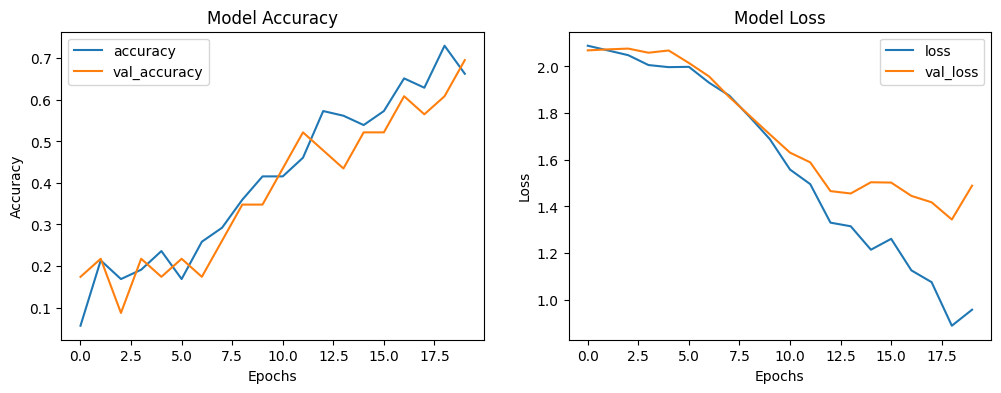

In [ ]:

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Model accuracy : 69.5652186870575


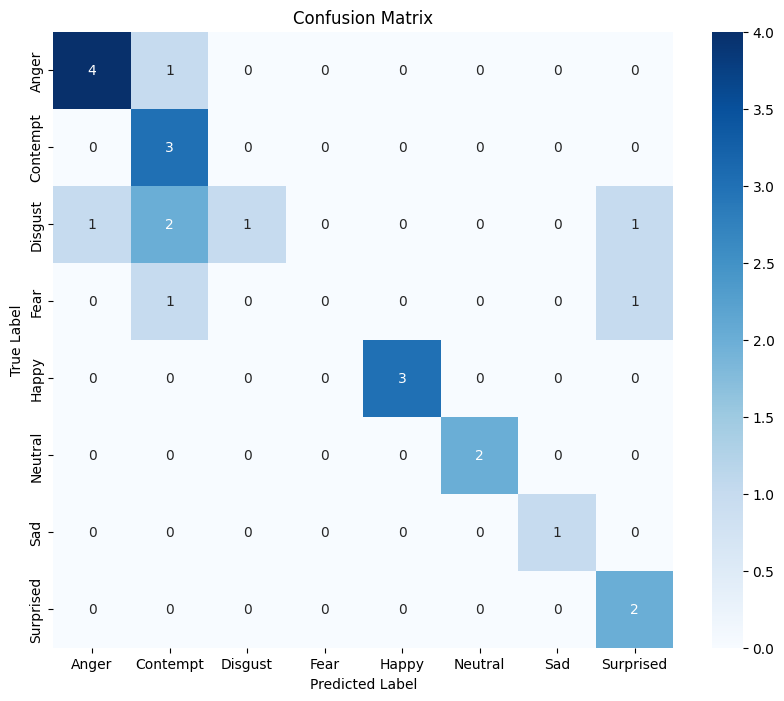

              precision    recall  f1-score   support

       Anger       0.80      0.80      0.80         5
    Contempt       0.43      1.00      0.60         3
     Disgust       1.00      0.20      0.33         5
        Fear       0.00      0.00      0.00         2
       Happy       1.00      1.00      1.00         3
     Neutral       1.00      1.00      1.00         2
         Sad       1.00      1.00      1.00         1
   Surprised       0.50      1.00      0.67         2

    accuracy                           0.70        23
   macro avg       0.72      0.75      0.68        23
weighted avg       0.75      0.70      0.64        23



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Model accuracy :", accuracy * 100)
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
cm_df = pd.DataFrame(cm, index=EMOTIONS, columns=EMOTIONS)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
report = classification_report(y_true, y_pred_classes, target_names=EMOTIONS)
print(report)

# Display images with predicted and actual labels

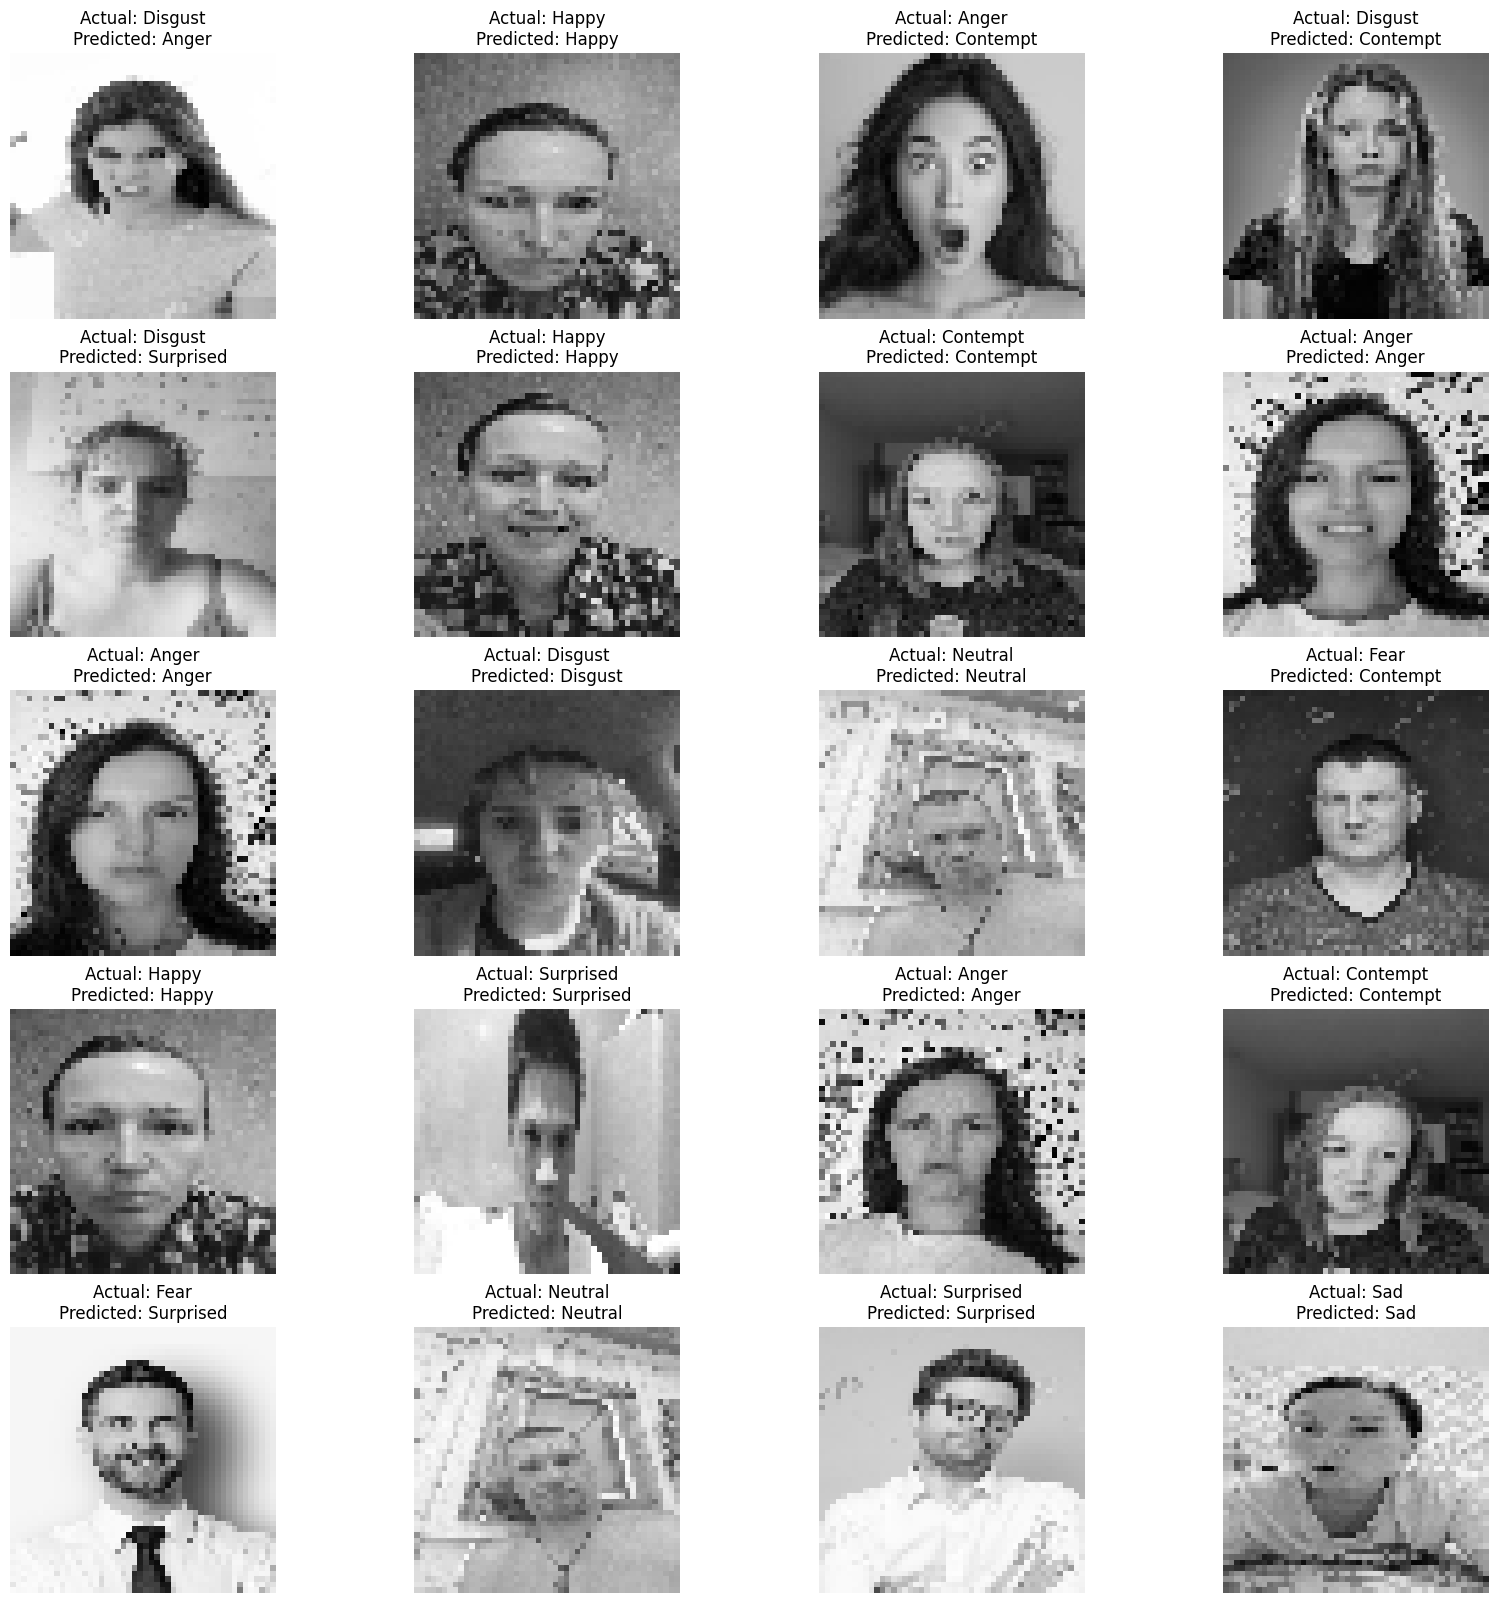

In [ ]:

num_images = min(20, len(X_test))
plt.figure(figsize=(20, 20))
for i in range(num_images):
    plt.subplot(5, 4, i + 1)
    img = (X_test[i] * 255).astype(np.uint8)  # Convert back to uint8
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for display
    plt.title(f"Actual: {EMOTIONS[y_true[i]]}\nPredicted: {EMOTIONS[y_pred_classes[i]]}")
    plt.axis('off')

plt.show()

# Create SVM model


In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
print(X_train.shape)

(89, 48, 48)


In [ ]:
X_train = X_train.reshape(X_train.shape[0], -1)
print(X_train.shape)

(89, 2304)


In [ ]:
y_train = y_train.reshape(y_train.shape[0], -1)

In [ ]:
print(y_train.shape)

(89, 8)


In [ ]:
print(X_test.shape)

(23, 48, 48)


In [ ]:
X_test = X_test.reshape((X_test.shape[0], -1))
print(X_test.shape)

(23, 2304)


Accuracy: 65.22%


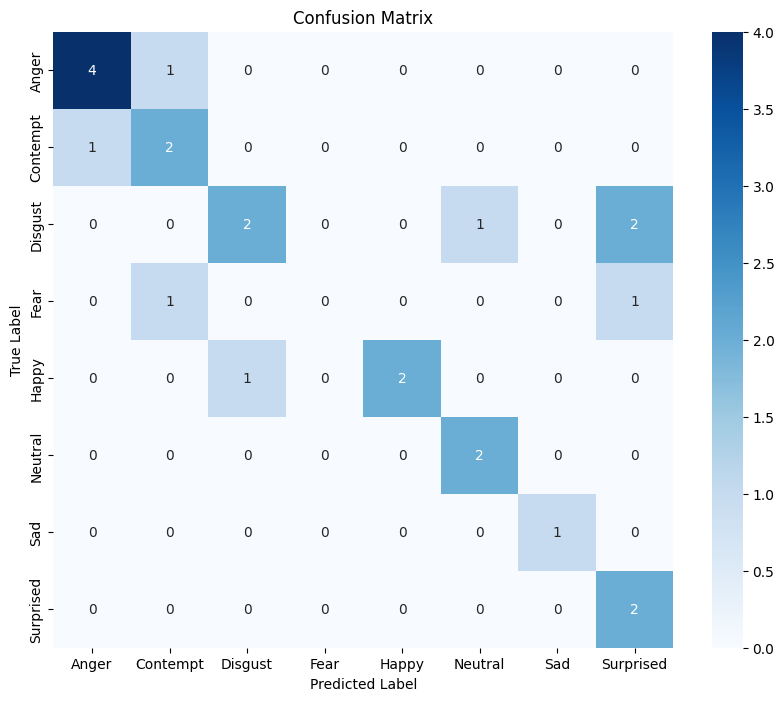

              precision    recall  f1-score   support

       Anger       0.80      0.80      0.80         5
    Contempt       0.50      0.67      0.57         3
     Disgust       0.67      0.40      0.50         5
        Fear       0.00      0.00      0.00         2
       Happy       1.00      0.67      0.80         3
     Neutral       0.67      1.00      0.80         2
         Sad       1.00      1.00      1.00         1
   Surprised       0.40      1.00      0.57         2

    accuracy                           0.65        23
   macro avg       0.63      0.69      0.63        23
weighted avg       0.65      0.65      0.62        23



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
# Create an SVM model (using the RBF kernel)
svm_model = SVC(kernel='rbf', C=1, gamma='scale')

# Train the model
svm_model.fit(X_train, np.argmax(y_train, axis=1))  # Convert y_train to 1D

# Make predictions
y_pred = svm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(np.argmax(y_test, axis=1), y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred)
cm_df = pd.DataFrame(cm, index=EMOTIONS, columns=EMOTIONS)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
report = classification_report(np.argmax(y_test, axis=1), y_pred, target_names=EMOTIONS)
print(report)

# KNN moddel

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Create the KNN model
knn_model = KNeighborsClassifier()

knn_model.fit(X_train,y_train)

KNeighborsClassifier()

Model accuracy : 60.86956521739131


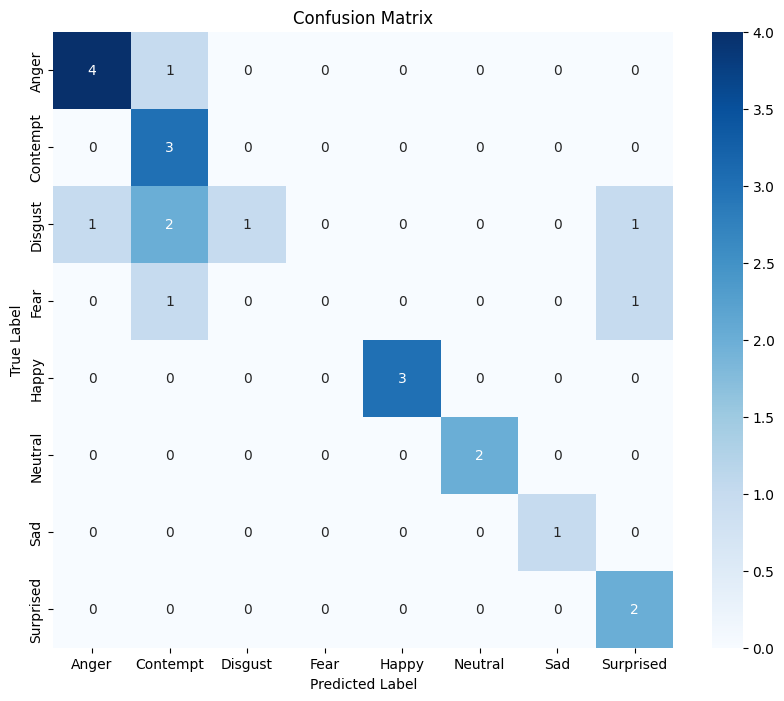

In [ ]:

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred_classes)
cm_df = pd.DataFrame(cm, index=EMOTIONS, columns=EMOTIONS)
print("Model accuracy :",knn_model.score(X_test,y_test)*100)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
report = classification_report(y_true, y_pred_classes, target_names=EMOTIONS)
print(report)

              precision    recall  f1-score   support

       Anger       0.80      0.80      0.80         5
    Contempt       0.43      1.00      0.60         3
     Disgust       1.00      0.20      0.33         5
        Fear       0.00      0.00      0.00         2
       Happy       1.00      1.00      1.00         3
     Neutral       1.00      1.00      1.00         2
         Sad       1.00      1.00      1.00         1
   Surprised       0.50      1.00      0.67         2

    accuracy                           0.70        23
   macro avg       0.72      0.75      0.68        23
weighted avg       0.75      0.70      0.64        23



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# MLP cllassifier


In [ ]:
from sklearn.neural_network import MLPClassifier
m_model= MLPClassifier()
m_model.fit(X_train,y_train)


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier()

Model accuracy : 60.86956521739131


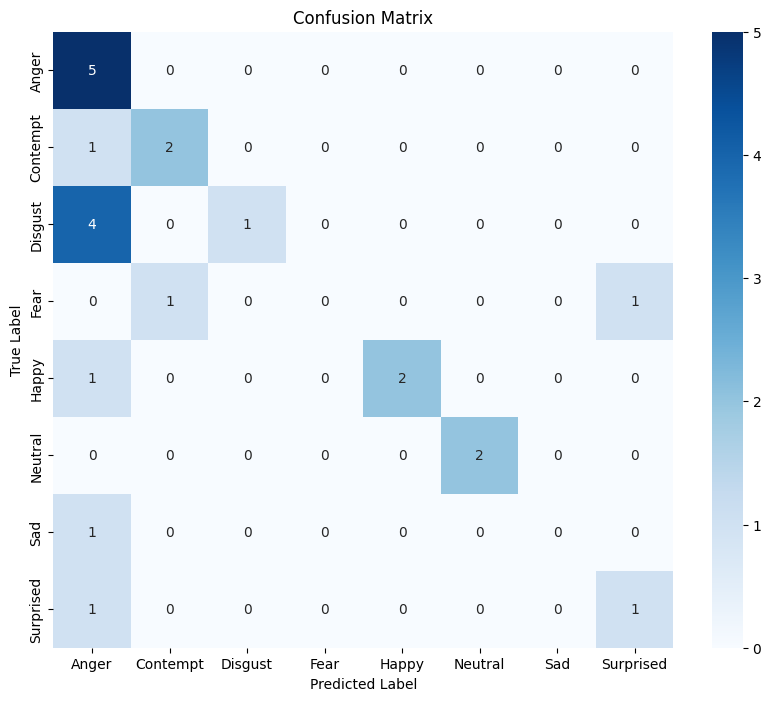

              precision    recall  f1-score   support

       Anger       0.38      1.00      0.56         5
    Contempt       0.67      0.67      0.67         3
     Disgust       1.00      0.20      0.33         5
        Fear       0.00      0.00      0.00         2
       Happy       1.00      0.67      0.80         3
     Neutral       1.00      1.00      1.00         2
         Sad       0.00      0.00      0.00         1
   Surprised       0.50      0.50      0.50         2

    accuracy                           0.57        23
   macro avg       0.57      0.50      0.48        23
weighted avg       0.65      0.57      0.51        23



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
y_pred_ = m_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_, axis=1)
y_true = np.argmax(y_test, axis=1)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred_classes)
cm_df = pd.DataFrame(cm, index=EMOTIONS, columns=EMOTIONS)
print("Model accuracy :",knn_model.score(X_test,y_test)*100)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
from sklearn.metrics import classification_report
report = classification_report(y_true, y_pred_classes, target_names=EMOTIONS)
print(report)